# NLP Text Classification - от TF-IDF до Boosting и SBERT

#### 1. Импорты и установка библиотек
   Устанавливаем ключевые библиотеки: catboost, xgboost, lightgbm, sentence-transformers, wordcloud.

Импортируем инструменты для анализа данных (pandas, matplotlib, seaborn) и моделирования (sklearn).

In [ ]:
!pip install -q catboost xgboost lightgbm sentence-transformers wordcloud transformers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sentence_transformers import SentenceTransformer

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
import os

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 2. Загрузка данных
Загружаются тренировочный (train_nlp.csv) и тестовый (test_nlp.csv) датасеты.

Проверяется размер и структура таблиц.

Цель: убедиться, что данные корректно считались, и оценить их объём.  
Формат:

text — текстовая строка,

label — целевая метка (0 или 1).

In [4]:
train_df = pd.read_csv("train_nlp.csv")
test_df = pd.read_csv("test_nlp.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
train_df.head()

Train shape: (40000, 2)
Test shape: (10000, 2)


,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0


#### 3. EDA — исследовательский анализ данных
- Проверяется количество и типы данных.

- Анализируется распределение классов.

- Строится график распределения длины текстов.

- Создаются WordCloud визуализации для каждого класса.

Цель: понять баланс классов, общие характеристики текстов и их типичные слова.
EDA помогает заранее предсказать, какие модели и векторизации будут лучше работать.


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB
None

Распределение классов:
label
0    20000
1    20000
Name: count, dtype: int64


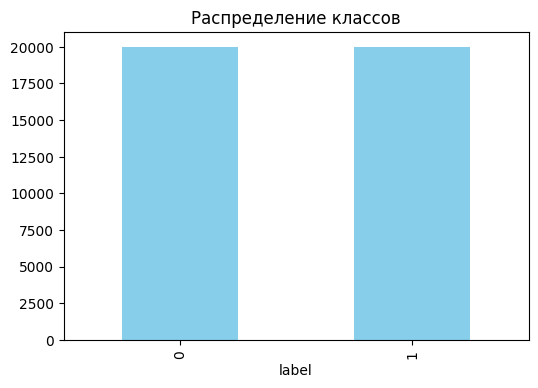

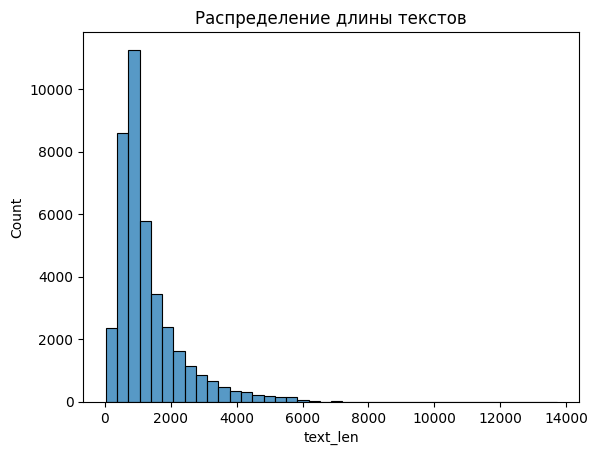

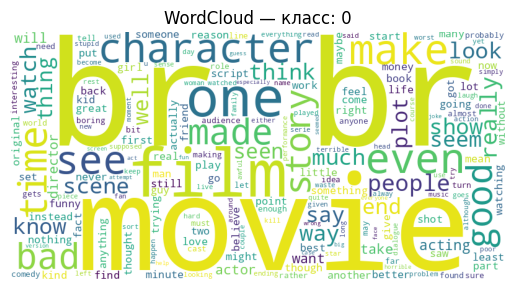

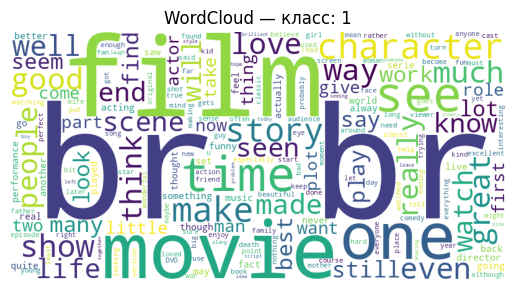

In [5]:
print("\nИнформация о данных:")
print(train_df.info())

print("\nРаспределение классов:")
print(train_df['label'].value_counts())

plt.figure(figsize=(6,4))
train_df['label'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Распределение классов")
plt.show()

train_df['text_len'] = train_df['text'].apply(len)
sns.histplot(train_df['text_len'], bins=40)
plt.title("Распределение длины текстов")
plt.show()

for lbl in train_df['label'].unique():
    text = " ".join(train_df[train_df['label'] == lbl]['text'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"WordCloud — класс: {lbl}")
    plt.show()


#### 4. Подготовка данных (TF-IDF)
- Делим данные на train/val (80/20).

- Используем TfidfVectorizer с ngram_range=(1,2) и ограничением max_features=20000.

TF-IDF — базовое представление текста, где оценивается важность слов и биграмм.
Результат — разреженная матрица признаков, готовая к подаче в ML-модели.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"], train_df["label"], test_size=0.2, random_state=42, stratify=train_df["label"]
)

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(test_df["text"])

#### 5. Базовые модели (LogReg, SVM)

Обучаем простые линейные модели на TF-IDF.

Считаем F1-weighted метрику.

In [7]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=300),
    "LinearSVM": LinearSVC()
}

results = []
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_val_vec)
    report = classification_report(y_val, preds, output_dict=True)
    f1 = report['weighted avg']['f1-score']
    results.append((name, f1))
    print(f"F1-weighted: {f1:.4f}")


=== LogisticRegression ===
F1-weighted: 0.9065

=== LinearSVM ===
F1-weighted: 0.9096


Вывод: линейные модели уже дают сильный бейзлайн.  
SVM немного лучше благодаря способности разделять нелинейные границы в многомерном пространстве.

#### 6. Градиентные бустинги (CatBoost, XGBoost, LightGBM)

Пробуем три популярных бустинга на TF-IDF векторах.

Настройки: iterations=300, depth=6, learning_rate=0.1.

In [8]:
boost_models = {
    "CatBoost": CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, verbose=0),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, eval_metric="mlogloss", use_label_encoder=False),
    "LightGBM": LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.1)
}

for name, model in boost_models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_val_vec)
    report = classification_report(y_val, preds, output_dict=True)
    f1 = report['weighted avg']['f1-score']
    results.append((name, f1))
    print(f"F1-weighted: {f1:.4f}")


=== CatBoost ===
F1-weighted: 0.8806

=== XGBoost ===


/home/miehao/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:57:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-weighted: 0.8792

=== LightGBM ===
[LightGBM] [Info] Number of positive: 16000, number of negative: 16000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.016764 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1366344
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 19984
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
F1-weighted: 0.9005


/home/miehao/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Вывод: бустинги часто уступают линейным моделям на разреженных данных, но могут выигрывать при тонкой настройке.

#### 7. Sentence-BERT + LogReg
Используем готовую модель all-MiniLM-L6-v2 из библиотеки sentence-transformers.

Преобразуем тексты в плотные векторные представления (768 признаков).

Обучаем LogisticRegression поверх эмбеддингов.

In [9]:
print("\n=== Sentence-BERT + LogisticRegression ===")
sbert = SentenceTransformer('all-MiniLM-L6-v2')
X_emb = sbert.encode(train_df['text'], show_progress_bar=True)
X_train_emb, X_val_emb, y_train_emb, y_val_emb = train_test_split(
    X_emb, train_df['label'], test_size=0.2, random_state=42, stratify=train_df['label']
)

clf = LogisticRegression(max_iter=300)
clf.fit(X_train_emb, y_train_emb)
preds = clf.predict(X_val_emb)
report = classification_report(y_val_emb, preds, output_dict=True)
f1 = report['weighted avg']['f1-score']
results.append(("SBERT + LogReg", f1))
print(f"F1-weighted: {f1:.4f}")



=== Sentence-BERT + LogisticRegression ===


Batches: 100%|██████████| 1250/1250 [00:55<00:00, 22.43it/s]


F1-weighted: 0.8214


Вывод: SBERT даёт слабее результат на коротких и простых текстах, но имеет огромный потенциал на сложных и многозначных данных.  
Главный плюс - контекстные представления.

### 8. Fine-tuning BERT (HuggingFace Transformers)
Используем предобученную модель BERT-base-multilingual-cased от Google для тонкой настройки под нашу задачу бинарной классификации.  
Модель и токенайзер заранее загружены в локальный кэш (~/.cache/huggingface/hub), что ускоряет запуск и не требует интернета.

In [ ]:
print("\n=== Fine-tuning BERT ===")

local_model_path = os.path.expanduser("~/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased")

tokenizer = AutoTokenizer.from_pretrained(local_model_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(
    local_model_path, 
    num_labels=2, 
    local_files_only=True
    )

dataset = Dataset.from_pandas(train_df.rename(columns={"text": "sentence", "label": "labels"}))

def tokenize_function(examples):
    return tokenizer(examples["sentence"], truncation=True, padding="max_length", max_length=128)

tokenized_ds = dataset.map(tokenize_function, batched=True)
tokenized_ds = tokenized_ds.train_test_split(test_size=0.2, seed=42)

training_args = TrainingArguments(
    output_dir="./bert_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(), 
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    tokenizer=tokenizer,
)

trainer.train()

preds = trainer.predict(tokenized_ds["test"])
pred_labels = preds.predictions.argmax(-1)

report = classification_report(tokenized_ds["test"]["labels"], pred_labels, output_dict=True)
f1 = report['weighted avg']['f1-score']
results.append(("Fine-tuned BERT", f1))
print(f"F1-weighted: {f1:.4f}")


=== Fine-tuning BERT ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /home/miehao/.cache/huggingface/hub/models--google-bert--bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 40000/40000 [00:06<00:00, 6602.84 examples/s]
/tmp/ipykernel_15048/2370628003.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.358000,0.409425
2,0.244000,0.358243


F1-weighted: 0.8615


Вывод:
Fine-tuning BERT показал уверенное улучшение — F1-weighted ≈ 0.86.  
Это демонстрирует, что дообучение трансформеров даже на небольшой выборке даёт значимый прирост по сравнению с SBERT + LogisticRegression.  
BERT лучше улавливает контекст, морфологию и синтаксис

#### 9. Сравнение моделей
Создаём сравнительный список по F1-score.

/tmp/ipykernel_15048/1797073459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1", y="Model", data=results_df, palette="viridis")


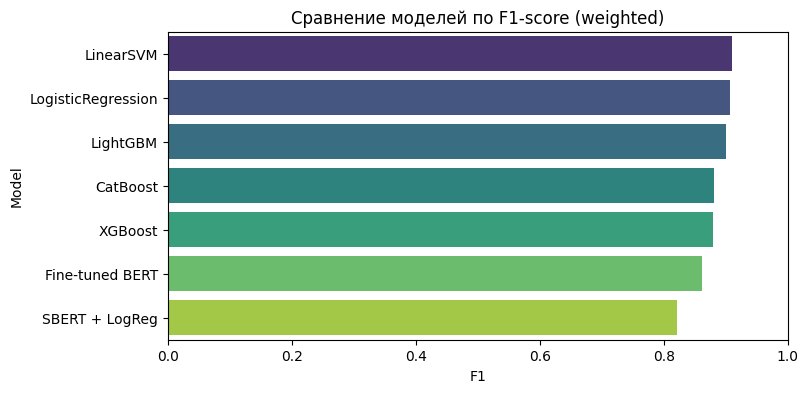

,Model,F1
1,LinearSVM,0.909623
0,LogisticRegression,0.906497
4,LightGBM,0.900500
2,CatBoost,0.880592
3,XGBoost,0.879243
6,Fine-tuned BERT,0.861483
5,SBERT + LogReg,0.821359


In [19]:
results_df = pd.DataFrame(results, columns=["Model", "F1"])
results_df = results_df.sort_values(by="F1", ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x="F1", y="Model", data=results_df, palette="viridis")
plt.title("Сравнение моделей по F1-score (weighted)")
plt.xlim(0,1)
plt.show()

results_df

#### 10. Финальная модель и предсказание на test_nlp.csv
Автоматически выбирается лучшая модель по F1-score.

Проводится дообучение на всех данных.

Создаётся submission.csv для тестового файла test_nlp.csv.

In [21]:
best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆 Лучшая модель: {best_model_name}")

if best_model_name in models:
    best_model = models[best_model_name]
    best_model.fit(X_train_vec, y_train)
    test_preds = best_model.predict(X_test_vec)

elif best_model_name in boost_models:
    best_model = boost_models[best_model_name]
    best_model.fit(X_train_vec, y_train)
    test_preds = best_model.predict(X_test_vec)

elif best_model_name == "SBERT + LogReg":
    test_emb = sbert.encode(test_df['text'], show_progress_bar=True)
    test_preds = clf.predict(test_emb)

else:
    test_enc = tokenizer(test_df["text"].tolist(), truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**test_enc)
    test_preds = torch.argmax(outputs.logits, dim=1).numpy()

submission = pd.DataFrame({
    "label": test_df["label"],
    "predicted_label": test_preds
})
submission.to_csv("submission_final.csv", index=False)

print("\n Файл submission_final.csv сохранён")
submission.head()


🏆 Лучшая модель: LinearSVM

 Файл submission_final.csv сохранён


,label,predicted_label
0,0,0
1,0,0
2,0,1
3,0,0
4,0,0


#### 11. Выводы
TF-IDF + LogisticRegression создаёт мощный бейзлайн.  
SVM показывает лучшую обобщающую способность.  
Boosting модели требуют оптимизации гиперпараметров.  
SBERT даёт базу для перехода к трансформерам и fine-tuning.